# 02 Baseline Model (CP1)

Цель: обучить baseline-модель (Logistic Regression) на базовых признаках без feature engineering и получить метрики на val/test.

In [1]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

In [2]:
ROOT = Path.cwd()
if not (ROOT / 'data' / 'processed' / 'train.csv').exists():
    ROOT = ROOT.parent

PROCESSED_DIR = ROOT / 'data' / 'processed'

train_df = pd.read_csv(PROCESSED_DIR / 'train.csv')
val_df = pd.read_csv(PROCESSED_DIR / 'val.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test.csv')

print('train:', train_df.shape)
print('val:', val_df.shape)
print('test:', test_df.shape)

train: (69999, 13)
val: (15000, 13)
test: (15001, 13)


In [3]:
TARGET = 'class'
BASE_FEATURES = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']

X_train = train_df[BASE_FEATURES]
y_train = train_df[TARGET]
X_val = val_df[BASE_FEATURES]
y_val = val_df[TARGET]
X_test = test_df[BASE_FEATURES]
y_test = test_df[TARGET]

In [4]:
baseline_model = Pipeline(
    steps=[
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, random_state=42)),
    ]
)

baseline_model.fit(X_train, y_train)

val_pred = baseline_model.predict(X_val)
test_pred = baseline_model.predict(X_test)

In [5]:
def compute_metrics(y_true, y_pred):
    return {
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
        'accuracy': accuracy_score(y_true, y_pred),
    }

val_metrics = compute_metrics(y_val, val_pred)
test_metrics = compute_metrics(y_test, test_pred)

print('Validation metrics:')
for k, v in val_metrics.items():
    print(f'  {k}: {v:.4f}')

print('\nTest metrics:')
for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

Validation metrics:
  macro_f1: 0.9508
  weighted_f1: 0.9568
  accuracy: 0.9571

Test metrics:
  macro_f1: 0.9516
  weighted_f1: 0.9574
  accuracy: 0.9578


In [6]:
print('Validation classification report:')
print(classification_report(y_val, val_pred, zero_division=0))

Validation classification report:
              precision    recall  f1-score   support

      GALAXY       0.96      0.96      0.96      8917
         QSO       0.95      0.89      0.91      2844
        STAR       0.95      1.00      0.97      3239

    accuracy                           0.96     15000
   macro avg       0.95      0.95      0.95     15000
weighted avg       0.96      0.96      0.96     15000



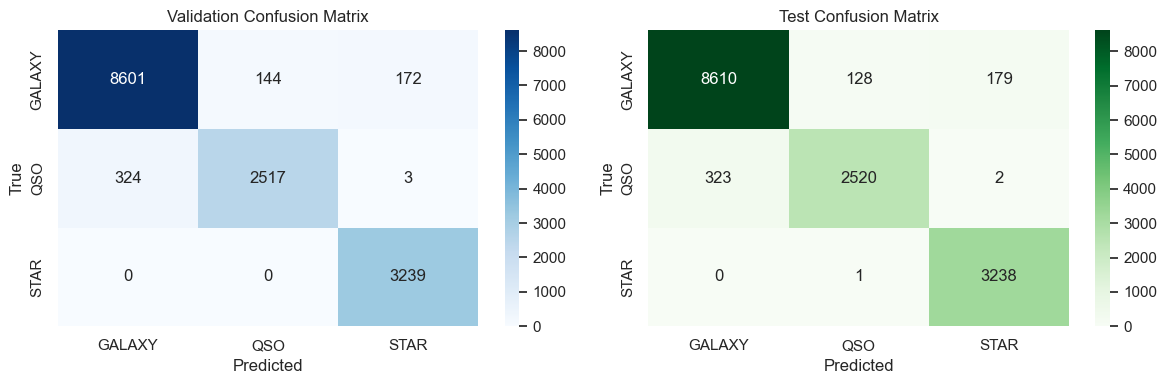

In [7]:
labels = sorted(train_df[TARGET].unique().tolist())

val_cm = confusion_matrix(y_val, val_pred, labels=labels)
test_cm = confusion_matrix(y_test, test_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(val_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

## Вывод

Baseline на Logistic Regression (без feature engineering, только базовые признаки) дал сильный старт:  
- `val`: Macro-F1 = 0.9508, Accuracy = 0.9571  
- `test`: Macro-F1 = 0.9516, Accuracy = 0.9578

Метрики на `val` и `test` близки, значит выраженного переобучения нет. По classification report видно, что сложнее всего распознаётся класс `QSO` (ниже recall), тогда как `STAR` и `GALAXY` определяются стабильнее. Этот baseline является корректной точкой отсчёта для следующих экспериментов.
